# Perceptron

## Overview

The **Perceptron**, introduced by Frank Rosenblatt in 1958, is the foundational building block of neural networks and one of the earliest supervised learning algorithms. It is a binary linear classifier that learns a decision boundary separating two classes by iteratively adjusting its weights based on misclassifications.

Despite its simplicity, the Perceptron laid the theoretical groundwork for modern deep learning.

---

## How It Works

The Perceptron models a single artificial neuron. Given an input vector **x** ∈ ℝⁿ, it computes a weighted sum and passes it through a step function:

$$\hat{y} = \begin{cases} 1 & \text{if } \mathbf{w} \cdot \mathbf{x} + b \geq 0 \\ 0 & \text{otherwise} \end{cases}$$

### Weight Update Rule

Learning occurs only when a prediction is wrong. For each misclassified sample:

$$\mathbf{w} \leftarrow \mathbf{w} + \eta (y_i - \hat{y}_i) \mathbf{x}_i$$
$$b \leftarrow b + \eta (y_i - \hat{y}_i)$$

where $\eta$ is the **learning rate**, $y_i$ is the true label, and $\hat{y}_i$ is the predicted label. If the prediction is correct, the update term is zero and weights remain unchanged.

---

## Key Properties

| Property | Detail |
|---|---|
| **Type** | Binary linear classifier |
| **Learning** | Online (sample-by-sample updates) |
| **Activation** | Heaviside step function |
| **Convergence** | Guaranteed only if data is linearly separable |
| **Limitation** | Cannot solve non-linearly separable problems (e.g., XOR) |

---

## Perceptron Convergence Theorem

If the training data is **linearly separable**, the Perceptron is guaranteed to converge to a solution in a finite number of steps. However, it offers no guarantee of convergence on non-separable data — it will cycle indefinitely.

---

## Relationship to Neural Networks

The Perceptron is effectively a neural network with:
- **One input layer** (the feature vector)
- **No hidden layers**
- **One output neuron** with a step activation

Stacking multiple Perceptrons with differentiable activations gives rise to the **Multilayer Perceptron (MLP)**, which can model non-linear decision boundaries.

 EXPERIMENT 1 — Linearly Separable vs XOR


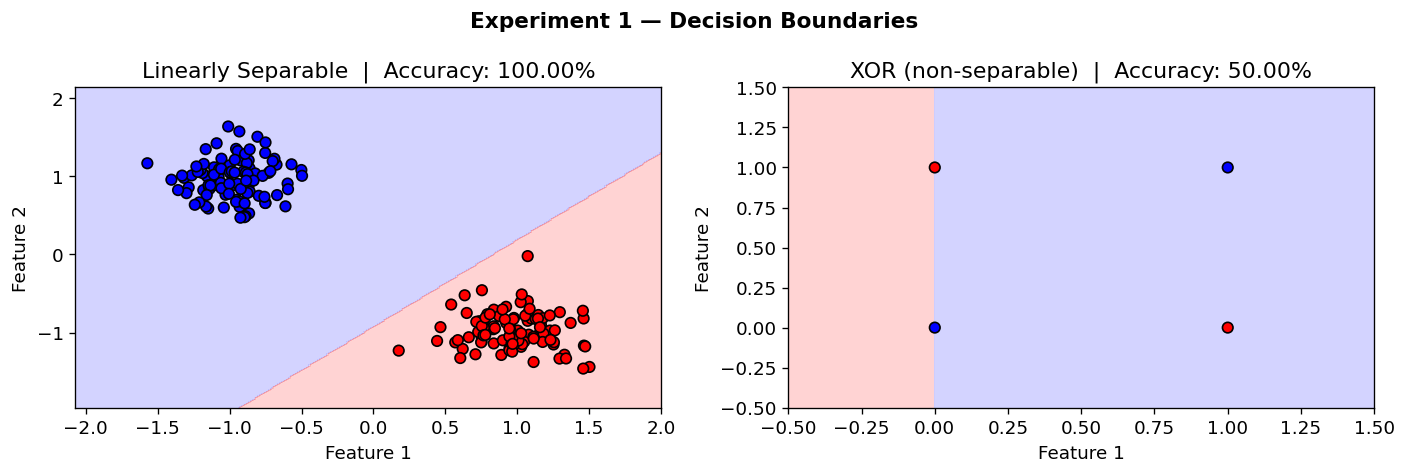

Separable accuracy : 100.00%
XOR accuracy       : 50.00%  (expected <100% — not linearly separable)

 EXPERIMENT 2 — Convergence Across Learning Rates


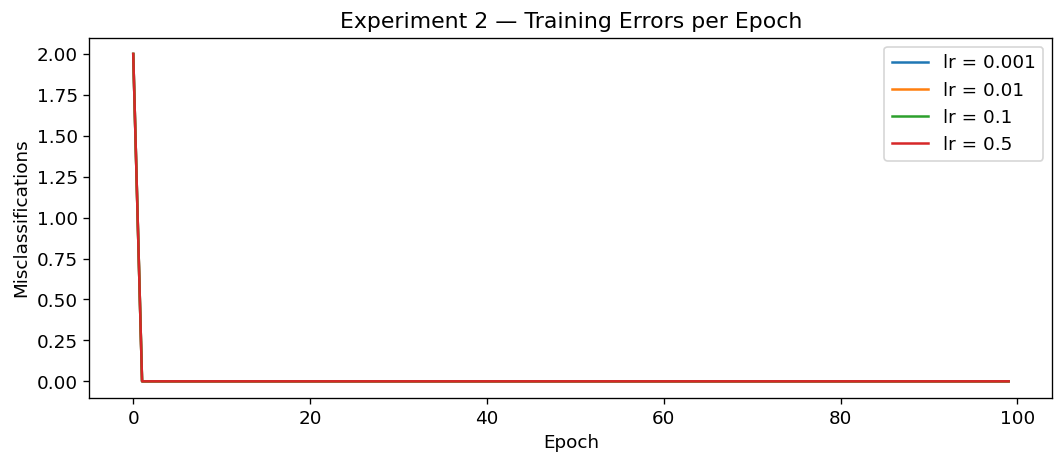

 EXPERIMENT 3 — Breast Cancer Dataset
Test Accuracy : 93.86%

              precision    recall  f1-score   support

   malignant       0.89      0.95      0.92        42
      benign       0.97      0.93      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



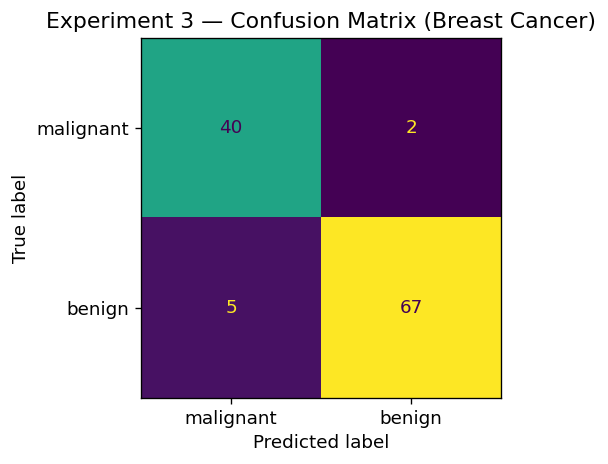

 EXPERIMENT 4 — Accuracy vs Iterations


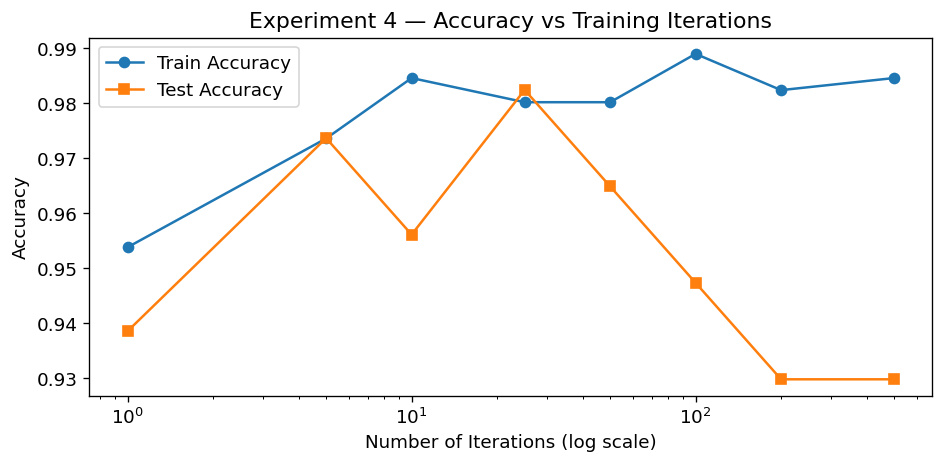

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.datasets import load_breast_cancer, make_blobs, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import sys
import os
sys.path.append(os.path.abspath("../../"))
from mlpackage import Perceptron

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

# ── 1. Helper: plot decision boundary ────────────────────────────────────────
def plot_decision_boundary(model, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.2, cmap="bwr")
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors="k", s=40)
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")


# ── 2. Linearly Separable vs XOR ─────────────────────────────────────────────
print("=" * 55)
print(" EXPERIMENT 1 — Linearly Separable vs XOR")
print("=" * 55)

X_sep, y_sep = make_blobs(n_samples=200, centers=2, cluster_std=0.9, random_state=42)
scaler = StandardScaler()
X_sep = scaler.fit_transform(X_sep)

X_xor = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_xor = np.array([0, 1, 1, 0])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Separable
p1 = Perceptron(learning_rate=0.1, n_iters=300)
p1.fit(X_sep, y_sep)
plot_decision_boundary(p1, X_sep, y_sep, axes[0],
    f"Linearly Separable  |  Accuracy: {p1.score(X_sep, y_sep):.2%}")

# XOR
p2 = Perceptron(learning_rate=0.1, n_iters=1000)
p2.fit(X_xor, y_xor)
plot_decision_boundary(p2, X_xor, y_xor, axes[1],
    f"XOR (non-separable)  |  Accuracy: {p2.score(X_xor, y_xor):.2%}")

plt.suptitle("Experiment 1 — Decision Boundaries", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print(f"Separable accuracy : {p1.score(X_sep, y_sep):.2%}")
print(f"XOR accuracy       : {p2.score(X_xor, y_xor):.2%}  (expected <100% — not linearly separable)\n")


# ── 3. Convergence — training error over epochs ───────────────────────────────
print("=" * 55)
print(" EXPERIMENT 2 — Convergence Across Learning Rates")
print("=" * 55)

X_conv, y_conv = make_blobs(n_samples=300, centers=2, cluster_std=1.0, random_state=7)
X_conv = StandardScaler().fit_transform(X_conv)

learning_rates = [0.001, 0.01, 0.1, 0.5]
fig, ax = plt.subplots(figsize=(9, 4))
for lr in learning_rates:
    p = Perceptron(learning_rate=lr, n_iters=100)
    p.fit(X_conv, y_conv)
    ax.plot(p.training_errors, label=f"lr = {lr}")

ax.set_xlabel("Epoch")
ax.set_ylabel("Misclassifications")
ax.set_title("Experiment 2 — Training Errors per Epoch")
ax.legend()
plt.tight_layout()
plt.show()


# ── 4. Real Dataset — Breast Cancer (2 PCA components for viz) ───────────────
print("=" * 55)
print(" EXPERIMENT 3 — Breast Cancer Dataset")
print("=" * 55)

data = load_breast_cancer()
X_raw, y_raw = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw)

sc = StandardScaler()
X_train_s = sc.fit_transform(X_train)
X_test_s  = sc.transform(X_test)

clf = Perceptron(learning_rate=0.1, n_iters=300)
clf.fit(X_train_s, y_train)
y_pred = clf.predict(X_test_s)

print(f"Test Accuracy : {clf.score(X_test_s, y_test):.2%}")
print()
print(classification_report(y_test, y_pred, target_names=data.target_names))

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=data.target_names).plot(ax=ax, colorbar=False)
ax.set_title("Experiment 3 — Confusion Matrix (Breast Cancer)")
plt.tight_layout()
plt.show()


# ── 5. Effect of number of iterations ────────────────────────────────────────
print("=" * 55)
print(" EXPERIMENT 4 — Accuracy vs Iterations")
print("=" * 55)

iter_range = [1, 5, 10, 25, 50, 100, 200, 500]
train_accs, test_accs = [], []

for n in iter_range:
    p = Perceptron(learning_rate=0.1, n_iters=n)
    p.fit(X_train_s, y_train)
    train_accs.append(p.score(X_train_s, y_train))
    test_accs.append(p.score(X_test_s, y_test))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(iter_range, train_accs, marker="o", label="Train Accuracy")
ax.plot(iter_range, test_accs,  marker="s", label="Test Accuracy")
ax.set_xscale("log")
ax.set_xlabel("Number of Iterations (log scale)")
ax.set_ylabel("Accuracy")
ax.set_title("Experiment 4 — Accuracy vs Training Iterations")
ax.legend()
plt.tight_layout()
plt.show()